# CNN Redshift Predictor - Local Training
Based on Li et al. 2024. Dual-branch CNN + NN for redshift prediction on 64x64 images.

In [16]:
import os
import numpy as np
import h5py                                    # read galaxy image HDF5 files
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import tensorflow.keras.backend as K

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


## Paths & Hyperparameters

In [17]:
TRAIN_PATH = '/Users/wen/Desktop/project/archive/5x64x64_training_with_morphology.hdf5'
VAL_PATH   = '/Users/wen/Desktop/project/archive/5x64x64_validation_with_morphology.hdf5'

MODEL_DIR  = '/Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output'
CKPT_PATH  = os.path.join(MODEL_DIR, 'checkpoints/cp.weights.h5')
CSV_LOG    = os.path.join(MODEL_DIR, 'training_log.csv')
os.makedirs(os.path.join(MODEL_DIR, 'checkpoints'), exist_ok=True)

BATCH_SIZE = 64
NUM_EPOCHS = 20
LR         = 1e-4
# 5-band magnitudes used as auxiliary features alongside the image
MAG_KEYS   = ['g_cmodel_mag', 'r_cmodel_mag', 'i_cmodel_mag', 'z_cmodel_mag', 'y_cmodel_mag']

Paths and hyperparameters set.
Checkpoints will be saved to: /Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output/checkpoints/


## Data Generator

In [18]:
# Custom Keras data generator that streams batches directly from the HDF5 file,
# avoiding loading the full dataset into memory.
class HDF5Generator(tf.keras.utils.Sequence):
    def __init__(self, path, batch_size=64, shuffle=True, mode="train"):
        self.path, self.batch_size, self.shuffle, self.mode = path, batch_size, shuffle, mode
        with h5py.File(path, "r") as f:
            self.n = f["image"].shape[0]
        self.indices = np.arange(self.n)
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(self.n / self.batch_size))

    def __getitem__(self, idx):
        # sort indices so HDF5 reads are sequential (much faster than random access)
        batch_idx = np.sort(self.indices[idx * self.batch_size:(idx + 1) * self.batch_size])
        with h5py.File(self.path, "r") as f:
            images = f["image"][batch_idx].astype("float32")  # (B, 5, 64, 64)
            labels = f["specz_redshift"][batch_idx].astype("float32")
            mags   = np.stack([f[k][batch_idx] for k in MAG_KEYS], axis=-1).astype("float32")

        # transpose to channels_last: (B, 64, 64, 5)
        images = np.transpose(images, (0, 2, 3, 1))

        # per-image min-max normalisation → pixel values in [0, 1]
        mins = images.min(axis=(1, 2, 3), keepdims=True)
        maxs = images.max(axis=(1, 2, 3), keepdims=True)
        images = (images - mins) / (maxs - mins + 1e-8)
        # magnitude normalisation: shift by typical sky magnitude (~20) and scale
        mags = (mags - 20.0) / 5.0
        return ((images, mags), labels) if self.mode == "train" else (images, mags)

    def on_epoch_end(self):
        # reshuffle index order after each epoch to vary batch composition
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = HDF5Generator(TRAIN_PATH, batch_size=BATCH_SIZE, shuffle=True,  mode="train")
val_gen   = HDF5Generator(VAL_PATH,   batch_size=BATCH_SIZE, shuffle=False, mode="train")
print(f"Train: {train_gen.n} images | Val: {val_gen.n} images")

Train: 204573 images | Val: 40914 images


## Build Model

In [19]:
# HSC photometric redshift loss (from HSC survey pipeline).
# L = mean(1 - 1/(1 + (dz/0.15)^2))
# Behaves like MSE for small errors but saturates for large ones,
# reducing the influence of catastrophic outliers on gradient updates.
def hsc_loss(z_spec, z_photo):
    dz = z_photo - z_spec
    return K.mean(1 - 1.0 / (1.0 + K.square(dz / 0.15)))

# Dual-branch architecture (following Li et al. 2024):
#   Branch 1 — CNN: processes 5-band 64x64 images through 7 conv layers → 32-dim vector
#   Branch 2 — NN:  processes 5 photometric magnitudes through 6 dense layers → 200-dim vector
#   Both branches are concatenated and passed to a final Dense(1) for redshift prediction.
def build_model():
    # channels_last (NHWC) — required for Mac CPU
    input_cnn = Input(shape=(64, 64, 5), name="image_input")
    x = Conv2D(32,  (3,3), activation="tanh", padding="same")(input_cnn)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(64,  (3,3), activation="tanh", padding="same")(x)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(128, (3,3), activation="tanh", padding="same")(x)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(256, (3,3), activation="tanh", padding="same")(x)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(256, (3,3), activation="tanh", padding="same")(x)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(512, (3,3), activation="relu", padding="same")(x)
    x = Conv2D(512, (3,3), activation="relu", padding="same")(x)
    x = Flatten()(x)
    x = Dense(512, activation="tanh")(x)
    x = Dense(128, activation="tanh")(x)
    cnn_out = Dense(32, activation="tanh")(x)   # 32-dim image feature vector

    input_nn = Input(shape=(5,), name="mag_input")
    y = Dense(200, activation="relu")(input_nn)
    y = Dense(200, activation="relu")(y)
    y = Dense(200, activation="relu")(y)
    y = Dense(200, activation="relu")(y)
    y = Dense(200, activation="relu")(y)
    nn_out = Dense(200, activation="relu")(y)   # 200-dim magnitude feature vector

    merged = Concatenate()([cnn_out, nn_out])   # 232-dim combined representation
    output = Dense(1)(merged)                   # single scalar: predicted redshift
    return Model(inputs=[input_cnn, input_nn], outputs=output)

model = build_model()
model.compile(optimizer=Adam(learning_rate=LR), loss=hsc_loss,
              metrics=[tf.keras.metrics.RootMeanSquaredError()])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 5) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │      1,472 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 32, 32,    │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_15… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 16, 16,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 8, 8, 128) │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_17… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 4, 4, 256) │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 4, 4, 256) │    590,080 │ max_pooling2d_18… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 2, 2, 256) │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mag_input           │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 2, 2, 512) │  1,180,160 │ max_pooling2d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 200)       │      1,200 │ mag_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 2, 2, 512) │  2,359,808 │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 200)       │     40,200 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2048)      │          0 │ conv2d_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 200)       │     40,200 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 512)       │  1,049,088 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 200)       │     40,200 │ dense_35[0][0]  

 Total params: 5,840,353 (22.28 MB)

 Trainable params: 5,840,353 (22.28 MB)

 Non-trainable params: 0 (0.00 B)

## Train

In [20]:
CKPT_EVERY = os.path.join(MODEL_DIR, 'checkpoints/epoch_{epoch:03d}.weights.h5')
CKPT_BEST  = os.path.join(MODEL_DIR, 'checkpoints/best.weights.h5')
os.makedirs(os.path.join(MODEL_DIR, 'checkpoints'), exist_ok=True)

# ── Resume from latest checkpoint if exists ───────────────────────────────────
# Allows interrupted training jobs to continue without restarting from scratch.
import glob
existing = sorted(glob.glob(os.path.join(MODEL_DIR, 'checkpoints/epoch_*.weights.h5')))
initial_epoch = 0
if existing:
    latest = existing[-1]
    model.load_weights(latest)
    initial_epoch = int(latest.split('epoch_')[1].split('.')[0])
    print(f"Resuming from epoch {initial_epoch} ({latest})")
else:
    print("Starting from scratch.")

# Save weights every 2 epochs (periodic snapshot) and separately track the best val_loss.
class SaveEvery2Epochs(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 2 == 0:
            path = CKPT_EVERY.format(epoch=epoch + 1)
            self.model.save_weights(path)

callbacks = [
    SaveEvery2Epochs(),
    ModelCheckpoint(CKPT_BEST, save_weights_only=True,
                    monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    CSVLogger(CSV_LOG, append=True),   # appends each epoch's metrics to training_log.csv
]

history = model.fit(train_gen, epochs=NUM_EPOCHS, initial_epoch=initial_epoch,
                    validation_data=val_gen, callbacks=callbacks, verbose=1)

print(f"Done. Checkpoints: {MODEL_DIR}/checkpoints/")
print(f"Log: {CSV_LOG}")

Starting from scratch.
Epoch 1/20
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.2599 - root_mean_squared_error: 0.5196
Epoch 1: val_loss improved from None to 0.19606, saving model to /Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output/checkpoints/best.weights.h5
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 624s 195ms/step - loss: 0.2240 - root_mean_squared_error: 0.4740 - val_loss: 0.1961 - val_root_mean_squared_error: 0.2984
Epoch 2/20
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.1824 - root_mean_squared_error: 0.3091
Epoch 2: val_loss improved from 0.19606 to 0.16391, saving model to /Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output/checkpoints/best.weights.h5
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 609s 190ms/step - loss: 0.1726 - root_mean_squared_error: 0.3075 - val_loss: 0.1639 - val_root_mean_squared_error: 0.3003
Epoch 3/20
3197/3197 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.1590 - root_mean_squared_error: 0.3371
Epoch 3: val_loss did

## Plot Training History

,epoch,loss,root_mean_squared_error,val_loss,val_root_mean_squared_error
0,0,0.224026,0.473957,0.196060,0.298386
1,1,0.172649,0.307471,0.163908,0.300340
2,2,0.158997,0.361426,0.166850,0.444129
3,3,0.144961,0.332317,0.142278,0.295142
4,4,0.142425,0.353895,0.159215,0.457577
5,5,0.150443,0.423353,0.145920,0.393153
6,6,0.125592,0.322371,0.116081,0.297485
7,7,0.112966,0.297985,0.118233,0.293486
8,8,0.107637,0.301164,0.108087,0.291604
9,9,0.103317,0.297582,0.107183,0.282103


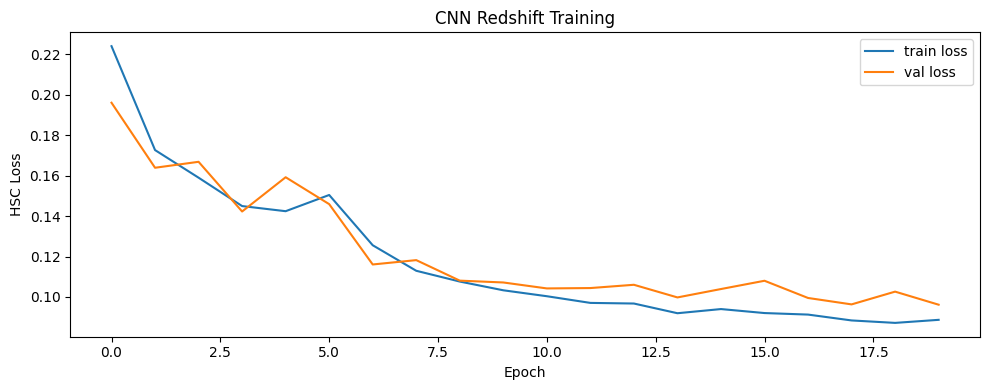

In [21]:
# Plot train vs val HSC loss curves to check for overfitting.
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.read_csv(CSV_LOG)
display(log_df)

plt.figure(figsize=(10, 4))
plt.plot(log_df["epoch"], log_df["loss"],     label="train loss")
plt.plot(log_df["epoch"], log_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("HSC Loss")
plt.legend()
plt.title("CNN Redshift Training")
plt.tight_layout()
plt.show()

In [22]:
# Print the last 10 rows of the training log: epoch, train loss, val loss, RMSE.
import pandas as pd
df = pd.read_csv('/Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output/training_log.csv')
print(df[['epoch', 'loss', 'val_loss', 'root_mean_squared_error']].tail(10))

    epoch      loss  val_loss  root_mean_squared_error
10     10  0.100384  0.104239                 0.287760
11     11  0.097081  0.104422                 0.295912
12     12  0.096773  0.106041                 0.296871
13     13  0.091975  0.099790                 0.290581
14     14  0.094034  0.103939                 0.301962
15     15  0.092060  0.108029                 0.294333
16     16  0.091305  0.099518                 0.292728
17     17  0.088408  0.096344                 0.292382
18     18  0.087200  0.102653                 0.292018
19     19  0.088710  0.096191                 0.286206
